In [ ]:
# clustering on email embedding with PCA

'''
pip install transformers
pip install sentence-transformers
pip install scikit-learn
'''

In [1]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import random

/var/folders/vt/p3vf9d352l7fsw1fclffgfsh0000gn/T/ipykernel_71460/2282187539.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sentence_transformers/cross_encoder/CrossEncoder.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange


In [2]:
# preferences for each cluster with longer and more subject lines
# generate using ChatGPT

subject_prefs_long = {
    1: [
        "Exclusive offer: 25% off on all items in our new collection for a limited time",
        "Flash sale: Get up to 50% discount on your favorite items this weekend only",
        "Special discount just for you: Save 30% on your next purchase",
        "Limited time offer: Buy one get one free on select items in our store",
        "Hurry up! Exclusive discounts on new arrivals for our valued customers",
        "Don't miss out: Up to 40% off on our latest products",
        "Exclusive sale: 20% off on all items until the end of the month",
        "Special promotion: Save up to 35% on our best-selling products",
        "Act now: Get 30% off on selected items for a limited time",
        "Limited offer: Enjoy 25% discount on your favorite products today",
        "Special deal: Buy two get one free on all our new arrivals",
        "Flash sale: 50% off on selected items for the next 24 hours",
        "Exclusive savings: Save up to 40% on our latest collections",
        "Limited time only: 20% off sitewide on all products",
        "Don't miss out: Special discounts on our new arrivals"
    ],
    2: [
        "Your feedback is valuable to us! Take a quick survey and let us know your thoughts",
        "Help us improve! Share your feedback and get a chance to win a gift card",
        "We want to hear from you: Complete our survey and enjoy a special discount",
        "Tell us what you think: Your feedback can help us serve you better",
        "Join our feedback program and get exclusive rewards",
        "Participate in our survey and receive a special thank you gift",
        "We value your opinion: Take our survey and get a discount on your next purchase",
        "Share your experience: Complete our feedback form and get rewarded",
        "Help us improve: Fill out our survey and get a chance to win exciting prizes",
        "Your opinion matters: Take our survey and enjoy special offers",
        "Customer feedback survey: Let us know your thoughts and get a discount",
        "We appreciate your feedback: Complete our survey for a special reward",
        "Tell us about your experience: Take our quick survey and get a gift card",
        "Help us serve you better: Share your feedback and receive a discount",
        "We want to hear from you: Complete our feedback survey and get rewarded"
    ],
    3: [
        "Discover our latest product updates and new releases today!",
        "Stay ahead with our new technology upgrades and product launches",
        "Check out the latest advancements in our product lineup",
        "Explore new features and improvements in our latest release",
        "Get the latest updates on our new products and technologies",
        "Stay informed with our latest product innovations and upgrades",
        "Learn about the new features in our latest product release",
        "Be the first to know about our new products and technologies",
        "Discover the new advancements in our latest product update",
        "Get the inside scoop on our latest product developments",
        "Find out about the new features in our latest product launch",
        "Stay up-to-date with our new product releases and updates",
        "Learn about the latest improvements in our product lineup",
        "Get the latest news on our product upgrades and innovations",
        "Discover the new technologies in our latest product release"
    ]
}

In [3]:
# generate the customer Email Response dataset

def generate_responses(num_customers, subject_prefs):
    customer_data = []
    for customer_id in range(1, num_customers + 1):
        cluster_id = (customer_id - 1) % 3 + 1
        num_emails = 10
        for _ in range(num_emails):
            if random.random() < 0.5:
                email_subject = random.choice(subject_prefs[cluster_id])
                response = 'Yes' if random.random() < 0.9 else 'No'
            else:
                non_preferred_subjects = [subj for cid, subjects in subject_prefs.items() if cid != cluster_id for subj in subjects]
                email_subject = random.choice(non_preferred_subjects)
                response = 'No' if random.random() < 0.8 else 'Yes'
            customer_data.append([customer_id, cluster_id, email_subject, response])
    return pd.DataFrame(customer_data, columns=['CustomerID', 'ClusterID', 'EmailSubjectLine', 'Response'])

In [4]:
df = generate_responses(3000, subject_prefs_long)

In [5]:
# create sentences, generate sentence embeddings, and average them per customer
def create_sentence(row):
    if row['Response'] == 'Yes':
        return f"I LIKE an email with subject line as '{row['EmailSubjectLine']}'"
    else:
        return f"I DON'T LIKE an email with subject line as '{row['EmailSubjectLine']}'"

In [6]:
df['Sentence'] = df.apply(create_sentence, axis=1)

In [7]:
df.head()

,CustomerID,ClusterID,EmailSubjectLine,Response,Sentence
0,1,1,Stay informed with our latest product innovati...,Yes,I LIKE an email with subject line as 'Stay inf...
1,1,1,Join our feedback program and get exclusive re...,No,I DON'T LIKE an email with subject line as 'Jo...
2,1,1,Find out about the new features in our latest ...,No,I DON'T LIKE an email with subject line as 'Fi...
3,1,1,Special deal: Buy two get one free on all our ...,Yes,I LIKE an email with subject line as 'Special ...
4,1,1,Stay ahead with our new technology upgrades an...,No,I DON'T LIKE an email with subject line as 'St...


In [8]:
model = SentenceTransformer('paraphrase-MiniLM-L6-v2')

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [9]:
df['Embedding'] = df['Sentence'].apply(lambda x: model.encode(x))

In [10]:
customer_embeddings = df.groupby('CustomerID')['Embedding'].apply(lambda x: np.mean(x.tolist(), axis=0))
customer_level_df = pd.DataFrame(customer_embeddings)
customer_level_df = customer_level_df.reset_index()
customer_level_df = pd.merge(customer_level_df, df[['CustomerID', 'ClusterID']].drop_duplicates(), on='CustomerID')

In [11]:
customer_level_df.head()

,CustomerID,Embedding,ClusterID
0,1,"[-0.4457121, -0.2681183, -0.090974316, -0.2583...",1
1,2,"[-0.38630903, -0.2889891, -0.039772462, -0.113...",2
2,3,"[-0.408679, -0.2682455, -0.058509964, -0.18290...",3
3,4,"[-0.3254819, -0.2242777, -0.05480216, -0.17746...",1
4,5,"[-0.43133813, -0.29457945, -0.086278215, -0.20...",2


In [12]:
print(customer_level_df['ClusterID'].value_counts())

ClusterID
1    1000
2    1000
3    1000
Name: count, dtype: int64


In [13]:
pca = PCA(n_components=6)
customer_embeddings_pca = pca.fit_transform(customer_level_df['Embedding'].tolist())

In [14]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_cluster_ids = kmeans.fit_predict(customer_embeddings_pca)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [15]:
customer_level_df['KMeansClusterID'] = kmeans_cluster_ids

In [16]:
pivot_table = pd.pivot_table(
    customer_level_df,
    values='CustomerID',
    index='ClusterID',
    columns='KMeansClusterID',
    aggfunc='count',
    fill_value=0
)

In [17]:
print(pivot_table)

KMeansClusterID    0    1    2
ClusterID                     
1                123   26  851
2                759   49  192
3                121  703  176


In [ ]:
##############################################################################################################################
##############################################################################################################################
##############################################################################################################################

In [ ]:
# Recommending email, text, voice, phone by tensorflow embeddings

In [39]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras import layers

In [28]:
# Seed for reproducibility
np.random.seed(42)

# Step 1: Create the df_basic dataset with 30000 customers

# Define the number of customers and treatments
num_customers = 30000
treatments = ['email', 'text', 'voice', 'phone']
num_clusters = 5

# Generate customer IDs and clusters
customer_ids = np.arange(1, num_customers + 1)
customer_clusters = np.random.choice([1, 2, 3, 4, 5], size=num_customers)

# Generate df_basic data
rows_list = []
for i in range(num_customers):
    cluster = customer_clusters[i]
    preferred_item = treatments[cluster-1] if cluster in [1, 2, 3, 4] else None
    num_items = np.random.randint(10, 21)
    for _ in range(num_items):
        item = np.random.choice(treatments)
        if preferred_item and item == preferred_item:
            u_original = 0.7
        else:
            u_original = 0.3
        response = np.random.binomial(1, u_original)
        rows_list.append([customer_clusters[i], customer_ids[i], item, u_original, response])

df_basic = pd.DataFrame(rows_list, columns=['cluster_id', 'customer_id', 'treatment_item', 'u_original', 'response_basic'])

In [30]:
# Step 2: Create the df_enhanced dataset

# Add additive factor (u_delta) and multiplicative factor (i_rate)
df_basic['u_delta'] = np.random.uniform(-0.2, 0.2, df_basic.shape[0])
df_basic['i_rate'] = np.random.choice([0.8, 1.2], size=df_basic.shape[0], p=[0.5, 0.5])

# Calculate final probability
df_basic['u_delta_plus_u_original'] = df_basic['u_original'] + df_basic['u_delta']
df_basic['final_probability'] = df_basic['u_delta_plus_u_original'] * df_basic['i_rate']
df_basic['final_probability'] = df_basic['final_probability'].clip(0, 1)  # Ensure probabilities are between 0 and 1

# Generate response based on final_probability for df_enhanced
df_basic['response'] = np.random.binomial(1, df_basic['final_probability'])

In [31]:
# Step 3: Split into training and testing datasets

# Basic dataset split
df_basic_train, df_basic_test = train_test_split(df_basic[['cluster_id', 'customer_id', 'treatment_item', 'u_original', 'response_basic']], test_size=0.33, random_state=42)

# Enhanced dataset split
df_enhanced_train, df_enhanced_test = train_test_split(df_basic[['cluster_id', 'customer_id', 'treatment_item', 'u_original', 'u_delta', 'i_rate', 'u_delta_plus_u_original', 'final_probability', 'response']], test_size=0.33, random_state=42)

print(df_basic_train.shape, df_basic_test.shape, df_enhanced_train.shape, df_enhanced_test.shape)

(301124, 5) (148316, 5) (301124, 9) (148316, 9)


In [34]:
df_basic_train

,cluster_id,customer_id,treatment_item,u_original,response_basic
43414,4,2899,phone,0.7,1
160701,4,10748,email,0.3,0
339825,4,22713,text,0.3,0
166206,5,11112,text,0.3,0
106328,4,7108,phone,0.7,1
...,...,...,...,...,...
259178,1,17346,voice,0.3,0
365838,2,24431,voice,0.3,0
131932,5,8820,voice,0.3,0
146867,4,9814,phone,0.7,0


In [35]:
# Calculate Naïve RMSE
def calculate_naive_rmse(train_df, test_df):
    # Calculate the global mean response in the training data
    global_mean = train_df['response_basic'].mean()

    # Naive RMSE on Train Data
    naive_rmse_train = np.sqrt(mean_squared_error(train_df['response_basic'], [global_mean] * len(train_df)))

    # Naive RMSE on Test Data
    naive_rmse_test = np.sqrt(mean_squared_error(test_df['response_basic'], [global_mean] * len(test_df)))

    return naive_rmse_train, naive_rmse_test

In [40]:
# Compute Naïve RMSE
naive_rmse_train, naive_rmse_test = calculate_naive_rmse(df_basic_train, df_basic_test)
print(f'Naïve RMSE on Train Data: {naive_rmse_train}')
print(f'Naïve RMSE on Test Data: {naive_rmse_test}')

Naïve RMSE on Train Data: 0.4851257011332436
Naïve RMSE on Test Data: 0.48466724389218496


In [41]:
# Function to build and train Matrix Factorization model using TensorFlow
def matrix_factorization(train_df, test_df, latent_dim=1, epochs=5):
    num_customers = train_df['customer_id'].nunique()
    num_items = train_df['treatment_item'].nunique()

    # Convert customer_id and treatment_item to categorical codes
    train_df['customer_id'] = train_df['customer_id'].astype('category').cat.codes.values
    train_df['treatment_item'] = train_df['treatment_item'].astype('category').cat.codes.values
    test_df['customer_id'] = test_df['customer_id'].astype('category').cat.codes.values
    test_df['treatment_item'] = test_df['treatment_item'].astype('category').cat.codes.values

    # Build the Matrix Factorization model
    customer_input = layers.Input(shape=[1], name='customer_id')
    item_input = layers.Input(shape=[1], name='treatment_item')

    customer_embedding = layers.Embedding(num_customers, latent_dim, name='customer_embedding')(customer_input)
    item_embedding = layers.Embedding(num_items, latent_dim, name='item_embedding')(item_input)

    customer_vec = layers.Flatten()(customer_embedding)
    item_vec = layers.Flatten()(item_embedding)

    dot_product = layers.Dot(axes=1)([customer_vec, item_vec])

    model = tf.keras.Model([customer_input, item_input], dot_product)
    model.compile(optimizer='adam', loss='mse')

    # Train the model
    model.fit([train_df['customer_id'], train_df['treatment_item']], train_df['response_basic'], epochs=epochs, verbose=1)

    # Predict on Train and Test data
    train_predictions = model.predict([train_df['customer_id'], train_df['treatment_item']])
    test_predictions = model.predict([test_df['customer_id'], test_df['treatment_item']])

    # Calculate RMSE for Train and Test
    mf_rmse_train = np.sqrt(mean_squared_error(train_df['response_basic'], train_predictions))
    mf_rmse_test = np.sqrt(mean_squared_error(test_df['response_basic'], test_predictions))

    return mf_rmse_train, mf_rmse_test

In [42]:
# Train Matrix Factorization model and compute RMSE
mf_rmse_train, mf_rmse_test = matrix_factorization(df_basic_train, df_basic_test, latent_dim=10, epochs=10)
print(f'Matrix Factorization RMSE on Train Data: {mf_rmse_train}')
print(f'Matrix Factorization RMSE on Test Data: {mf_rmse_test}')

Epoch 1/10
9411/9411 ━━━━━━━━━━━━━━━━━━━━ 9s 917us/step - loss: 0.3446
Epoch 2/10
9411/9411 ━━━━━━━━━━━━━━━━━━━━ 9s 919us/step - loss: 0.2439
Epoch 3/10
9411/9411 ━━━━━━━━━━━━━━━━━━━━ 9s 909us/step - loss: 0.1973
Epoch 4/10
9411/9411 ━━━━━━━━━━━━━━━━━━━━ 9s 931us/step - loss: 0.1788
Epoch 5/10
9411/9411 ━━━━━━━━━━━━━━━━━━━━ 9s 922us/step - loss: 0.1707
Epoch 6/10
9411/9411 ━━━━━━━━━━━━━━━━━━━━ 9s 926us/step - loss: 0.1676
Epoch 7/10
9411/9411 ━━━━━━━━━━━━━━━━━━━━ 9s 930us/step - loss: 0.1646
Epoch 8/10
9411/9411 ━━━━━━━━━━━━━━━━━━━━ 9s 937us/step - loss: 0.1627
Epoch 9/10
9411/9411 ━━━━━━━━━━━━━━━━━━━━ 9s 910us/step - loss: 0.1617
Epoch 10/10
9411/9411 ━━━━━━━━━━━━━━━━━━━━ 9s 917us/step - loss: 0.1609
9411/9411 ━━━━━━━━━━━━━━━━━━━━ 2s 212us/step
4635/4635 ━━━━━━━━━━━━━━━━━━━━ 1s 215us/step
Matrix Factorization RMSE on Train Data: 0.3846392014549271
Matrix Factorization RMSE on Test Data: 0.577476225166707


In [47]:
df_basic_train['customer_id'].astype('category').cat.codes.values

array([ 2898, 10747, 22712, ...,  8819,  9813,  8148], dtype=int16)

In [48]:
import tensorflow as tf
from tensorflow.keras import layers, regularizers

# Function to build and train Matrix Factorization model with L2 and dropout regularization
def matrix_factorization(train_df, test_df, latent_dim=10, epochs=10, l2_reg=0.0, dropout_rate=0.0):
    num_customers = train_df['customer_id'].nunique()
    num_items = train_df['treatment_item'].nunique()

    # Convert customer_id and treatment_item to categorical codes
    train_df['customer_id'] = train_df['customer_id'].astype('category').cat.codes.values
    train_df['treatment_item'] = train_df['treatment_item'].astype('category').cat.codes.values
    test_df['customer_id'] = test_df['customer_id'].astype('category').cat.codes.values
    test_df['treatment_item'] = test_df['treatment_item'].astype('category').cat.codes.values

    # Build the Matrix Factorization model with L2 regularization and dropout
    customer_input = layers.Input(shape=[1], name='customer_id')
    item_input = layers.Input(shape=[1], name='treatment_item')

    customer_embedding = layers.Embedding(num_customers, latent_dim,
                                          embeddings_regularizer=regularizers.l2(l2_reg),
                                          name='customer_embedding')(customer_input)
    item_embedding = layers.Embedding(num_items, latent_dim,
                                      embeddings_regularizer=regularizers.l2(l2_reg),
                                      name='item_embedding')(item_input)

    customer_vec = layers.Flatten()(customer_embedding)
    item_vec = layers.Flatten()(item_embedding)

    # Add Dropout
    customer_vec = layers.Dropout(dropout_rate)(customer_vec)
    item_vec = layers.Dropout(dropout_rate)(item_vec)

    dot_product = layers.Dot(axes=1)([customer_vec, item_vec])

    model = tf.keras.Model([customer_input, item_input], dot_product)
    model.compile(optimizer='adam', loss='mse')

    # Train the model
    model.fit([train_df['customer_id'], train_df['treatment_item']], train_df['response_basic'], batch_size=1024,
              epochs=epochs, verbose=1)

    # Predict on Train and Test data
    train_predictions = model.predict([train_df['customer_id'], train_df['treatment_item']])
    test_predictions = model.predict([test_df['customer_id'], test_df['treatment_item']])

    # Calculate RMSE for Train and Test
    mf_rmse_train = np.sqrt(mean_squared_error(train_df['response_basic'], train_predictions))
    mf_rmse_test = np.sqrt(mean_squared_error(test_df['response_basic'], test_predictions))

    return mf_rmse_train, mf_rmse_test

In [49]:
from sklearn.metrics import mean_squared_error

# Define grid search parameters
l2_values = [0.0001, 0.0005]
dropout_rates = [0.0001]

# Initialize variables to store the best results
best_rmse_train = float('inf')
best_rmse_test = float('inf')
best_l2 = None
best_dropout = None

# Grid search over l2 and dropout_rate
for l2 in l2_values:
    for dropout in dropout_rates:
        print(f"Training with L2: {l2} and Dropout: {dropout}")
        mf_rmse_train, mf_rmse_test = matrix_factorization(df_basic_train, df_basic_test,
                                                           latent_dim=5, epochs=30,
                                                           l2_reg=l2, dropout_rate=dropout)
        print(f"Train RMSE: {mf_rmse_train}, Test RMSE: {mf_rmse_test}\n")

        # Update best results if this model is better
        if mf_rmse_test < best_rmse_test:
            best_rmse_train = mf_rmse_train
            best_rmse_test = mf_rmse_test
            best_l2 = l2
            best_dropout = dropout

# Print the best regularization settings
print(f"Best L2: {best_l2}, Best Dropout: {best_dropout}")
print(f"Best Train RMSE: {best_rmse_train}, Best Test RMSE: {best_rmse_test}")

Training with L2: 0.0001 and Dropout: 0.0001
Epoch 1/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 1s 970us/step - loss: 0.3791
Epoch 2/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3466
Epoch 3/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2943
Epoch 4/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 0s 997us/step - loss: 0.2735
Epoch 5/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2662
Epoch 6/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2623
Epoch 7/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2600
Epoch 8/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2579
Epoch 9/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 0s 980us/step - loss: 0.2573
Epoch 10/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2561
Epoch 11/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2550
Epoch 12/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2536
Epoch 13/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 0s 966us/step - loss: 0.2516
Epoch 14/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 0s 963us/step - loss: 0.2487
Ep

In [52]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, Flatten, Concatenate, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2

# Function for matrix factorization with concatenated embeddings and regularization
def matrix_factorization_with_concatenated_embeddings(df_train, df_test, embedding_size=5, l2_reg=0.001, dropout_rate=0.1):
    # Convert customer_id and treatment_item to categorical codes
    df_train['customer_id'] = df_train['customer_id'].astype('category').cat.codes.values
    df_train['treatment_item'] = df_train['treatment_item'].astype('category').cat.codes.values
    df_test['customer_id'] = df_test['customer_id'].astype('category').cat.codes.values
    df_test['treatment_item'] = df_test['treatment_item'].astype('category').cat.codes.values

    # Input layers
    customer_input = Input(shape=(1,), name='customer_input')
    item_input = Input(shape=(1,), name='item_input')
    u_delta_input = Input(shape=(1,), name='u_delta_input')
    i_rate_input = Input(shape=(1,), name='i_rate_input')

    # Embedding layers
    customer_embedding = Embedding(input_dim=len(df_train['customer_id'].unique()), output_dim=embedding_size,
                                   embeddings_regularizer=l2(l2_reg), name='customer_embedding')(customer_input)
    item_embedding = Embedding(input_dim=len(df_train['treatment_item'].unique()), output_dim=embedding_size,
                               embeddings_regularizer=l2(l2_reg), name='item_embedding')(item_input)

    # Flatten embeddings
    customer_vec = Flatten()(customer_embedding)
    item_vec = Flatten()(item_embedding)

    # Concatenate embeddings and additional features
    concat = Concatenate()([customer_vec, item_vec, u_delta_input, i_rate_input])

    # Add dense layers with regularization
    dense = Dense(128, activation='relu', kernel_regularizer=l2(l2_reg))(concat)
    dropout = Dropout(dropout_rate)(dense)
    dense = Dense(64, activation='relu', kernel_regularizer=l2(l2_reg))(dropout)
    output = Dense(1, activation='sigmoid')(dense)

    # Model
    model = Model(inputs=[customer_input, item_input, u_delta_input, i_rate_input], outputs=output)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=[tf.keras.metrics.RootMeanSquaredError()])

    # Prepare input data for the model
    X_train = [df_train['customer_id'], df_train['treatment_item'], df_train['u_delta'], df_train['i_rate']]
    y_train = df_train['response']
    X_test = [df_test['customer_id'], df_test['treatment_item'], df_test['u_delta'], df_test['i_rate']]
    y_test = df_test['response']

    # Train the model
    model.fit(X_train, y_train, epochs=30, batch_size=50000, validation_data=(X_test, y_test))

    # Predictions
    train_predictions = model.predict(X_train)
    test_predictions = model.predict(X_test)

    # Compute RMSE
    train_rmse = np.sqrt(np.mean((train_predictions.flatten() - y_train) ** 2))
    test_rmse = np.sqrt(np.mean((test_predictions.flatten() - y_test) ** 2))

    return train_rmse, test_rmse

In [53]:
# Example usage
l2_values = [0.01]
dropout_rates = [0.005]

for l2_reg in l2_values:
    for dropout_rate in dropout_rates:
        print(f"Evaluating with L2 Regularization: {l2_reg}, Dropout Rate: {dropout_rate}")
        train_rmse, test_rmse = matrix_factorization_with_concatenated_embeddings(df_enhanced_train, df_enhanced_test,
                                                                                  embedding_size=30,
                                                                                  l2_reg=l2_reg,
                                                                                  dropout_rate=dropout_rate)
        print(f"Train RMSE: {train_rmse}, Test RMSE: {test_rmse}\n")

Evaluating with L2 Regularization: 0.01, Dropout Rate: 0.005
Epoch 1/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 9.1657 - root_mean_squared_error: 0.4948 - val_loss: 6.9620 - val_root_mean_squared_error: 0.4892
Epoch 2/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 6.4489 - root_mean_squared_error: 0.4884 - val_loss: 4.8787 - val_root_mean_squared_error: 0.4868
Epoch 3/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 4.5263 - root_mean_squared_error: 0.4865 - val_loss: 3.4667 - val_root_mean_squared_error: 0.4859
Epoch 4/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 3.2365 - root_mean_squared_error: 0.4858 - val_loss: 2.5542 - val_root_mean_squared_error: 0.4853
Epoch 5/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 2.4100 - root_mean_squared_error: 0.4852 - val_loss: 1.9867 - val_root_mean_squared_error: 0.4848
Epoch 6/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 1.8992 - root_mean_squared_error: 0.4851 - val_loss: 1.6408 - val_root_mean_squared_error: 0.4845
Epoch 7/3

In [ ]:
##############################################################################################################################

In [ ]:
# catboost

In [55]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Seed for reproducibility
np.random.seed(42)

# Step 1: Create the df_basic dataset with 30000 customers

# Define the number of customers and treatments
num_customers = 100000
treatments = ['email', 'text', 'voice', 'phone']
num_clusters = 5

# Generate customer IDs and clusters
customer_ids = np.arange(1, num_customers + 1)
customer_clusters = np.random.choice([1, 2, 3, 4, 5], size=num_customers)

# Generate df_basic data
rows_list = []
for i in range(num_customers):
    cluster = customer_clusters[i]
    preferred_item = treatments[cluster-1] if cluster in [1, 2, 3, 4] else None
    num_items = np.random.randint(50, 51)
    for _ in range(num_items):
        item = np.random.choice(treatments)
        if preferred_item and item == preferred_item:
            u_original = 0.7
        else:
            u_original = 0.3
        response = np.random.binomial(1, u_original)
        rows_list.append([customer_clusters[i], customer_ids[i], item, u_original, response])

df_basic = pd.DataFrame(rows_list, columns=['cluster_id', 'customer_id', 'treatment_item', 'u_original', 'response_basic'])

# Step 2: Create the df_enhanced dataset

# Add additive factor (u_delta) and multiplicative factor (i_rate)
df_basic['u_delta'] = np.random.uniform(-0.2, 0.2, df_basic.shape[0])
df_basic['i_rate'] = np.random.choice([0.8, 1.2], size=df_basic.shape[0], p=[0.5, 0.5])

# Calculate final probability
df_basic['u_delta_plus_u_original'] = df_basic['u_original'] + df_basic['u_delta']
df_basic['final_probability'] = df_basic['u_delta_plus_u_original'] * df_basic['i_rate']

# Adjust final probability based on cluster_id
df_basic.loc[df_basic['cluster_id'] == 1, 'final_probability'] += 0.15
df_basic.loc[df_basic['cluster_id'] == 2, 'final_probability'] *= 1.15
df_basic.loc[df_basic['cluster_id'] == 3, 'final_probability'] -= 0.15
df_basic.loc[df_basic['cluster_id'] == 4, 'final_probability'] *= 0.85

# Ensure probabilities are between 0 and 1
df_basic['final_probability'] = df_basic['final_probability'].clip(0, 1)

# Generate response based on final_probability for df_enhanced
df_basic['response'] = np.random.binomial(1, df_basic['final_probability'])

# Step 3: Split into training and testing datasets

# Basic dataset split
df_basic_train, df_basic_test = train_test_split(df_basic[['cluster_id', 'customer_id', 'treatment_item', 'u_original', 'response_basic']], test_size=0.33, random_state=42)

# Enhanced dataset split
df_enhanced_train, df_enhanced_test = train_test_split(df_basic[['cluster_id', 'customer_id', 'treatment_item', 'u_original', 'u_delta', 'i_rate', 'u_delta_plus_u_original', 'final_probability', 'response']], test_size=0.33, random_state=42)

print(df_basic_train.shape, df_basic_test.shape, df_enhanced_train.shape, df_enhanced_test.shape)

(3350000, 5) (1650000, 5) (3350000, 9) (1650000, 9)


In [57]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, roc_auc_score
from catboost import CatBoostRegressor

# Prepare the data
X_train = df_enhanced_train[['customer_id', 'treatment_item', 'u_delta', 'i_rate']]
y_train = df_enhanced_train['response']
X_test = df_enhanced_test[['customer_id', 'treatment_item', 'u_delta', 'i_rate']]
y_test = df_enhanced_test['response']

# Specify categorical features (CatBoost automatically handles these correctly)
categorical_features = ['customer_id', 'treatment_item']

# Initialize the CatBoostRegressor model
model = CatBoostRegressor(iterations=200,
                          learning_rate=0.1,
                          depth=4,
                          l2_leaf_reg=3,
                          loss_function='RMSE',
                          cat_features=categorical_features,
                          verbose=10)

# Train the model
model.fit(X_train, y_train, eval_set=(X_test, y_test), verbose=True)

# Predict on training and testing datasets
train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

# Compute RMSE for training and testing datasets
train_rmse = np.sqrt(mean_squared_error(y_train, train_predictions))
test_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))

print(f'Train RMSE: {train_rmse}, Test RMSE: {test_rmse}')

# Compute ROC AUC for training and testing datasets
train_auc = roc_auc_score(y_train, train_predictions)
test_auc = roc_auc_score(y_test, test_predictions)

print(f'Train AUC: {train_auc}, Test AUC: {test_auc}')

0:	learn: 0.4815297	test: 0.4815153	best: 0.4815153 (0)	total: 303ms	remaining: 1m
1:	learn: 0.4782045	test: 0.4779461	best: 0.4779461 (1)	total: 533ms	remaining: 52.8s
2:	learn: 0.4754364	test: 0.4749834	best: 0.4749834 (2)	total: 758ms	remaining: 49.8s
3:	learn: 0.4731826	test: 0.4725301	best: 0.4725301 (3)	total: 908ms	remaining: 44.5s
4:	learn: 0.4712856	test: 0.4704672	best: 0.4704672 (4)	total: 1.12s	remaining: 43.5s
5:	learn: 0.4696746	test: 0.4687134	best: 0.4687134 (5)	total: 1.27s	remaining: 41.2s
6:	learn: 0.4683505	test: 0.4672434	best: 0.4672434 (6)	total: 1.41s	remaining: 38.9s
7:	learn: 0.4672279	test: 0.4659990	best: 0.4659990 (7)	total: 1.56s	remaining: 37.4s
8:	learn: 0.4651159	test: 0.4629891	best: 0.4629891 (8)	total: 1.8s	remaining: 38.1s
9:	learn: 0.4633644	test: 0.4607585	best: 0.4607585 (9)	total: 1.94s	remaining: 36.8s
10:	learn: 0.4618983	test: 0.4586338	best: 0.4586338 (10)	total: 2.08s	remaining: 35.7s
11:	learn: 0.4606454	test: 0.4569707	best: 0.4569707 (11

In [ ]:
# Thompson Sampling Multi-Armed Bandit Reinforcement Learning by channel sequence

Day 1 Simulation


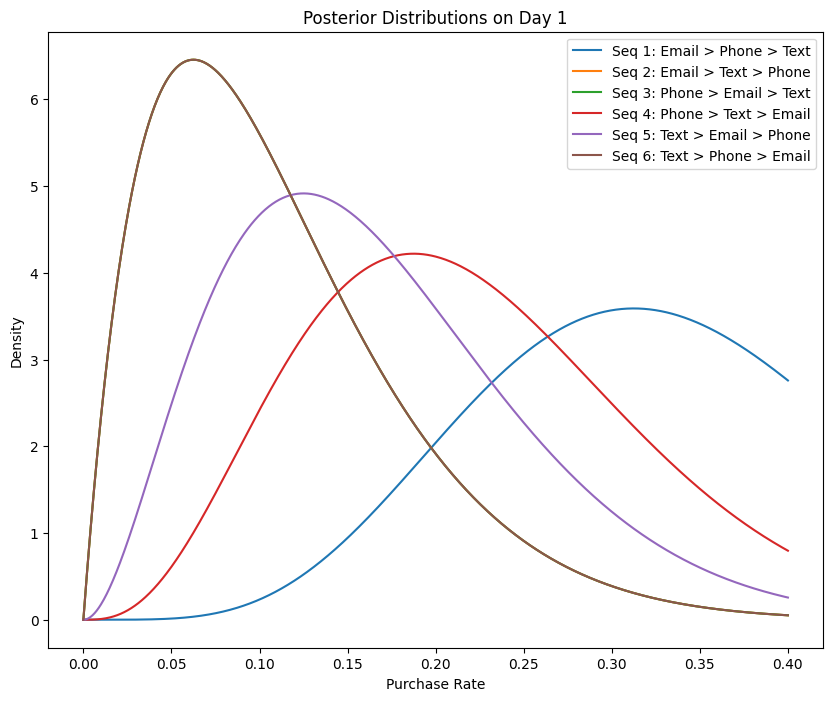

Sequence 1 (Email > Phone > Text) was assigned to 63 customers.
Sequence 2 (Email > Text > Phone) was assigned to 3 customers.
Sequence 3 (Phone > Email > Text) was assigned to 0 customers.
Sequence 4 (Phone > Text > Email) was assigned to 23 customers.
Sequence 5 (Text > Email > Phone) was assigned to 9 customers.
Sequence 6 (Text > Phone > Email) was assigned to 2 customers.
--------------------------------------------------
Day 2 Simulation


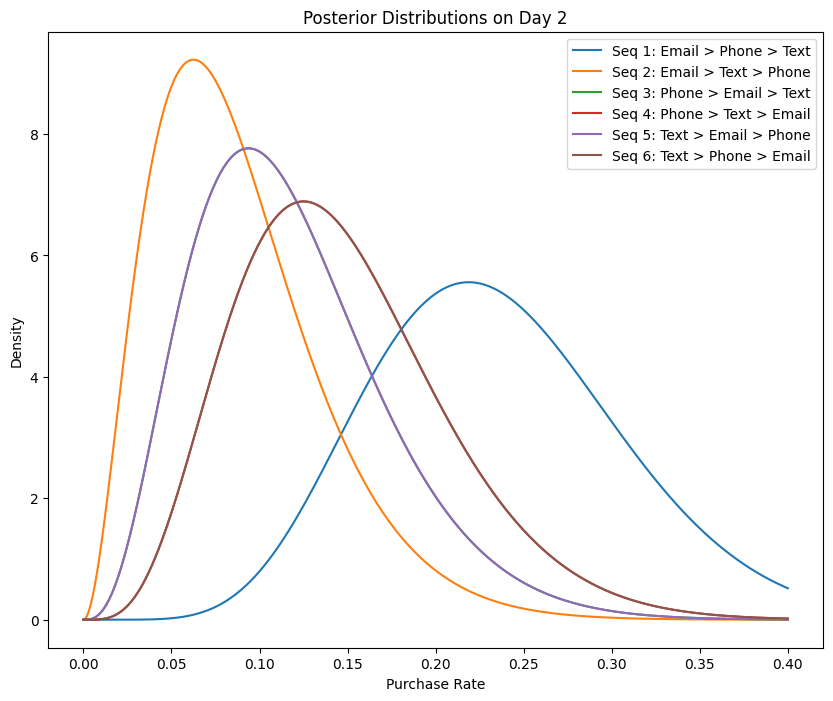

Sequence 1 (Email > Phone > Text) was assigned to 70 customers.
Sequence 2 (Email > Text > Phone) was assigned to 0 customers.
Sequence 3 (Phone > Email > Text) was assigned to 5 customers.
Sequence 4 (Phone > Text > Email) was assigned to 12 customers.
Sequence 5 (Text > Email > Phone) was assigned to 3 customers.
Sequence 6 (Text > Phone > Email) was assigned to 10 customers.
--------------------------------------------------
Day 3 Simulation


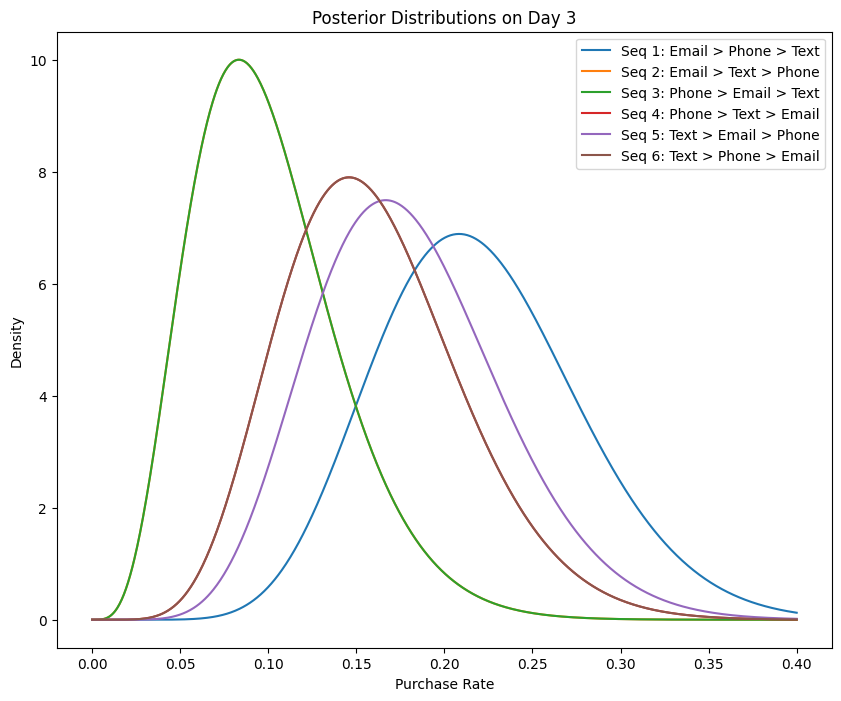

Sequence 1 (Email > Phone > Text) was assigned to 55 customers.
Sequence 2 (Email > Text > Phone) was assigned to 1 customers.
Sequence 3 (Phone > Email > Text) was assigned to 0 customers.
Sequence 4 (Phone > Text > Email) was assigned to 11 customers.
Sequence 5 (Text > Email > Phone) was assigned to 21 customers.
Sequence 6 (Text > Phone > Email) was assigned to 12 customers.
--------------------------------------------------
Day 4 Simulation


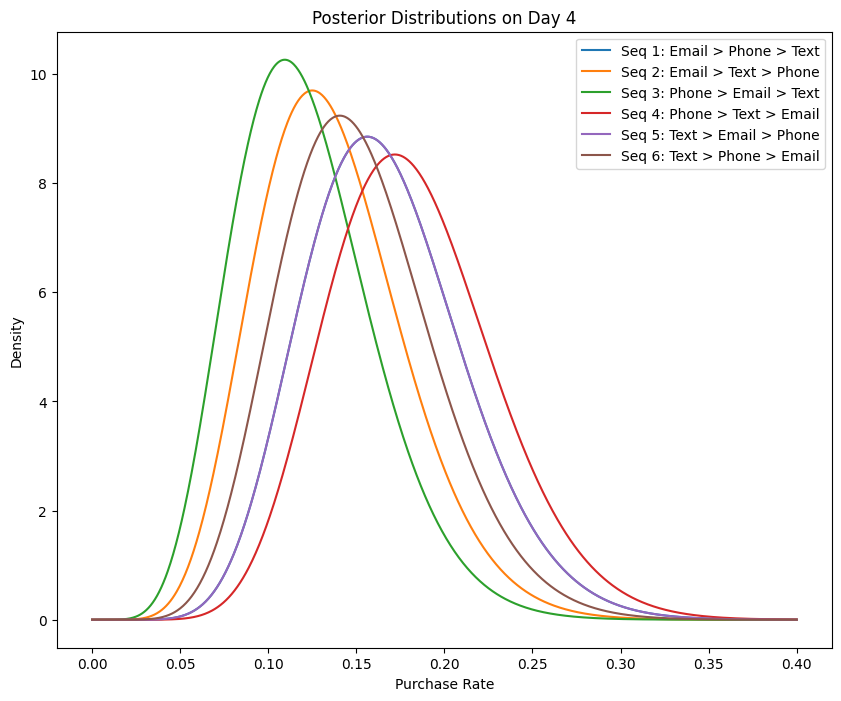

Sequence 1 (Email > Phone > Text) was assigned to 18 customers.
Sequence 2 (Email > Text > Phone) was assigned to 8 customers.
Sequence 3 (Phone > Email > Text) was assigned to 2 customers.
Sequence 4 (Phone > Text > Email) was assigned to 35 customers.
Sequence 5 (Text > Email > Phone) was assigned to 18 customers.
Sequence 6 (Text > Phone > Email) was assigned to 19 customers.
--------------------------------------------------
Day 5 Simulation


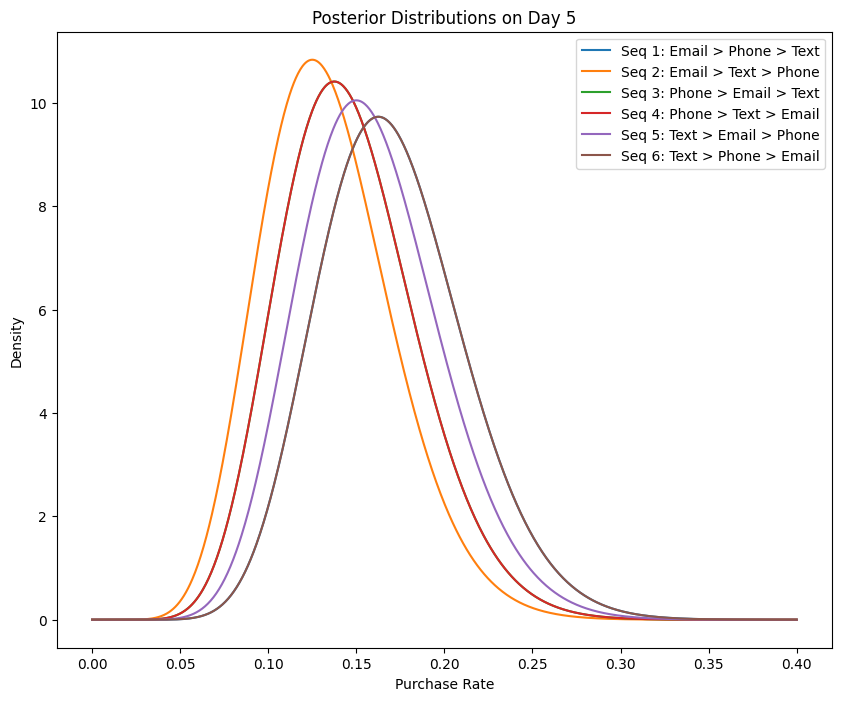

Sequence 1 (Email > Phone > Text) was assigned to 21 customers.
Sequence 2 (Email > Text > Phone) was assigned to 5 customers.
Sequence 3 (Phone > Email > Text) was assigned to 10 customers.
Sequence 4 (Phone > Text > Email) was assigned to 14 customers.
Sequence 5 (Text > Email > Phone) was assigned to 21 customers.
Sequence 6 (Text > Phone > Email) was assigned to 29 customers.
--------------------------------------------------
Day 6 Simulation


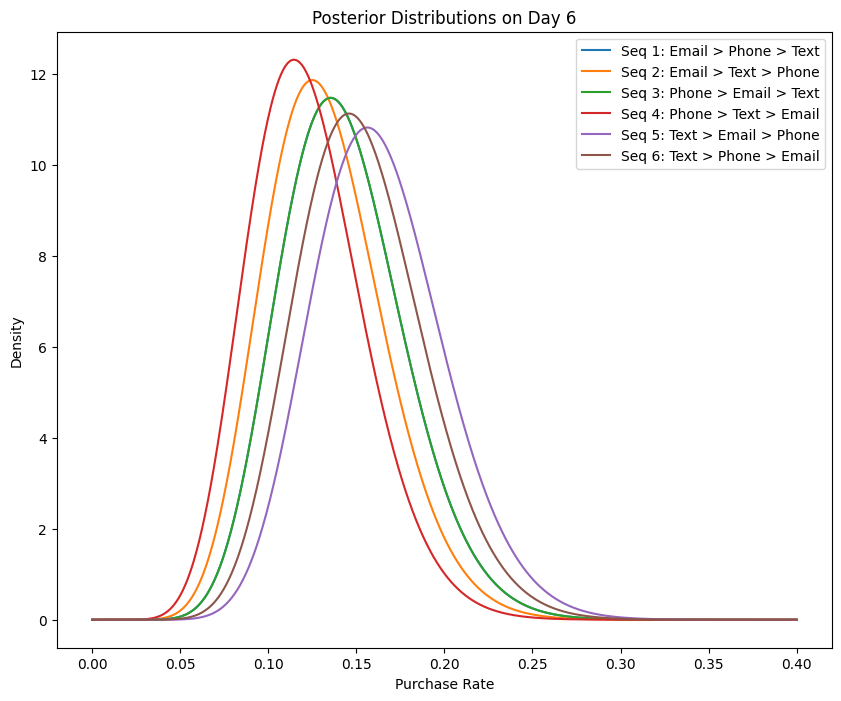

Sequence 1 (Email > Phone > Text) was assigned to 15 customers.
Sequence 2 (Email > Text > Phone) was assigned to 6 customers.
Sequence 3 (Phone > Email > Text) was assigned to 21 customers.
Sequence 4 (Phone > Text > Email) was assigned to 5 customers.
Sequence 5 (Text > Email > Phone) was assigned to 36 customers.
Sequence 6 (Text > Phone > Email) was assigned to 17 customers.
--------------------------------------------------
Day 7 Simulation


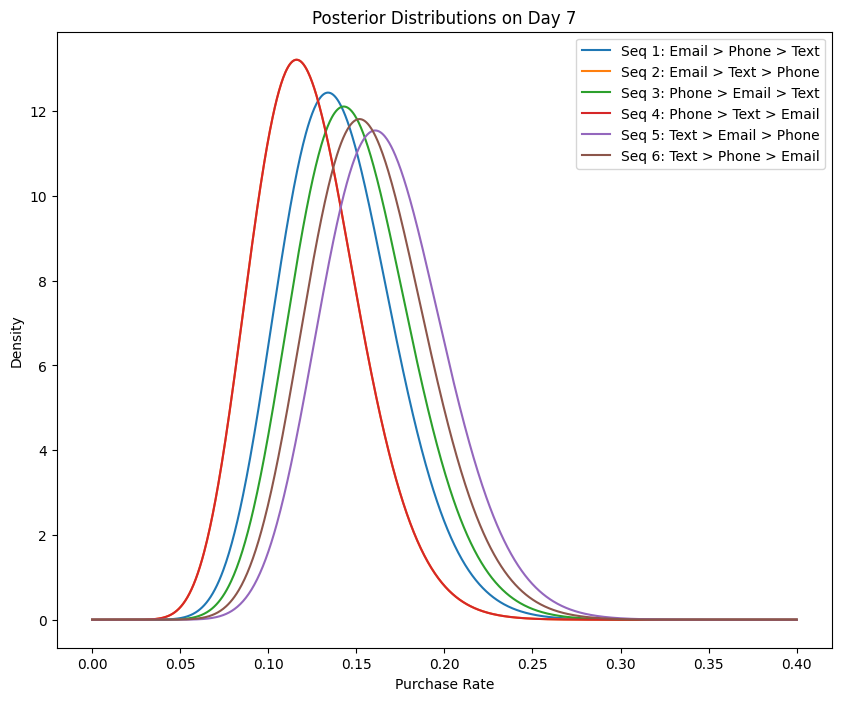

Sequence 1 (Email > Phone > Text) was assigned to 8 customers.
Sequence 2 (Email > Text > Phone) was assigned to 3 customers.
Sequence 3 (Phone > Email > Text) was assigned to 19 customers.
Sequence 4 (Phone > Text > Email) was assigned to 3 customers.
Sequence 5 (Text > Email > Phone) was assigned to 37 customers.
Sequence 6 (Text > Phone > Email) was assigned to 30 customers.
--------------------------------------------------
Day 8 Simulation


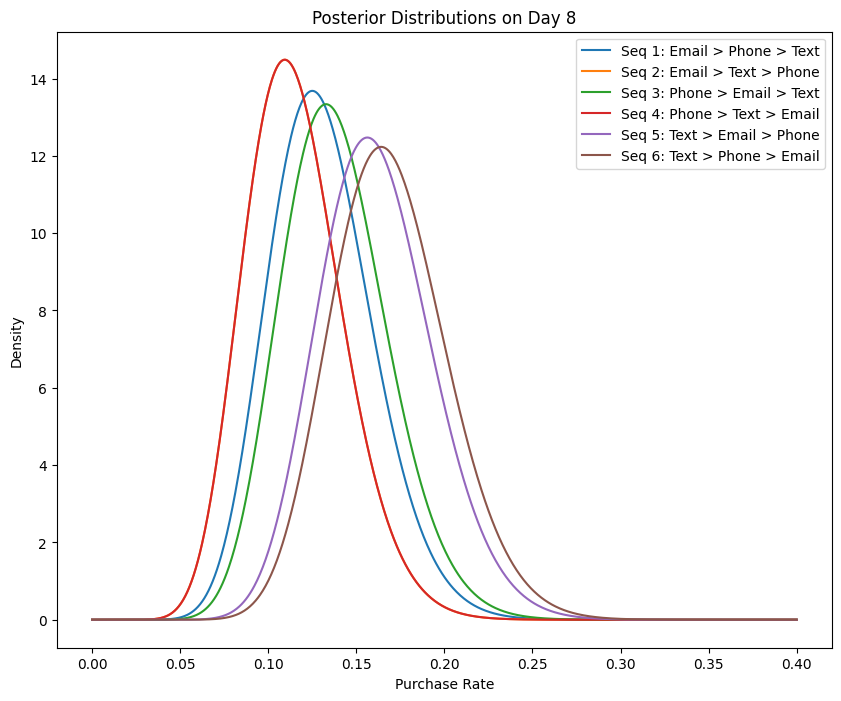

Sequence 1 (Email > Phone > Text) was assigned to 7 customers.
Sequence 2 (Email > Text > Phone) was assigned to 3 customers.
Sequence 3 (Phone > Email > Text) was assigned to 18 customers.
Sequence 4 (Phone > Text > Email) was assigned to 3 customers.
Sequence 5 (Text > Email > Phone) was assigned to 24 customers.
Sequence 6 (Text > Phone > Email) was assigned to 45 customers.
--------------------------------------------------
Day 9 Simulation


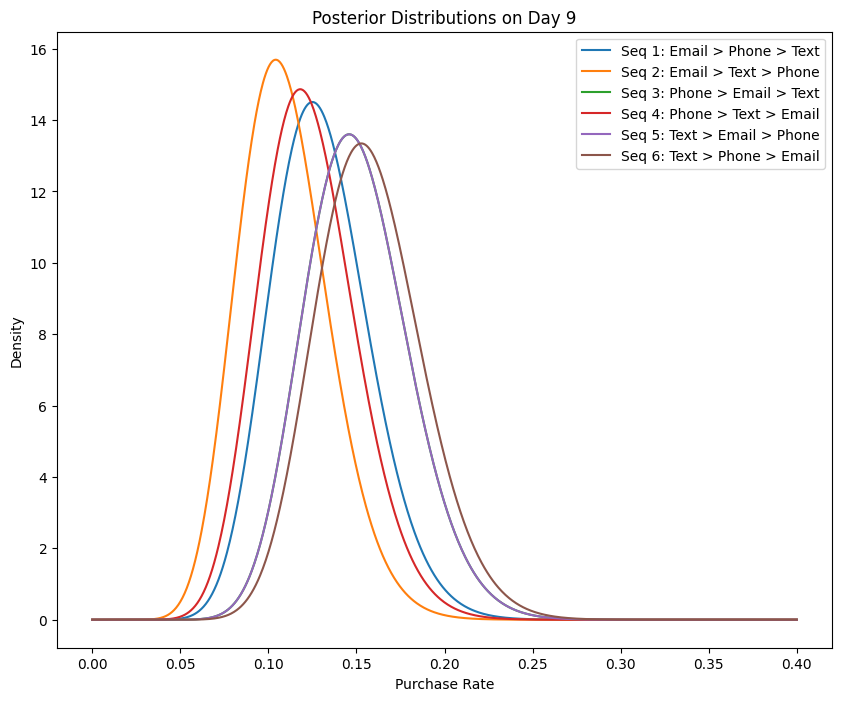

Sequence 1 (Email > Phone > Text) was assigned to 12 customers.
Sequence 2 (Email > Text > Phone) was assigned to 1 customers.
Sequence 3 (Phone > Email > Text) was assigned to 25 customers.
Sequence 4 (Phone > Text > Email) was assigned to 3 customers.
Sequence 5 (Text > Email > Phone) was assigned to 20 customers.
Sequence 6 (Text > Phone > Email) was assigned to 39 customers.
--------------------------------------------------


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

# Define the 6 possible sequences (permutations of Email, Phone, Text)
sequences = {
    1: 'Email > Phone > Text',
    2: 'Email > Text > Phone',
    3: 'Phone > Email > Text',
    4: 'Phone > Text > Email',
    5: 'Text > Email > Phone',
    6: 'Text > Phone > Email'
}

# True (but unobserved) purchase rates for each sequence
true_purchase_rates = {
    1: 0.15,
    2: 0.10,
    3: 0.12,
    4: 0.08,
    5: 0.18,
    6: 0.14
}

# Number of customers per day
num_customers_per_day = 100

# Initialize the prior parameters for Beta distributions (uniform prior)
# Reason of using beta is because it is a conjugate prior
# Beta distribution is used to model random variables that are bounded between 0 and 1
# making it particularly useful for representing probablities and proportions
posteriors = {seq: {'alpha': 1, 'beta': 1} for seq in sequences.keys()}

# Function to simulate customer purchase responses based on true rates
def simulate_responses(true_rates, num_customers):
    responses = {}
    for seq, rate in true_rates.items():
        # Simulate 0/1 outcomes for each sequence based on the true purchase rate
        responses[seq] = np.random.binomial(1, rate, num_customers // len(true_rates))
    return responses

# Function to update posteriors based on observed responses
def update_posteriors(posteriors, responses):
    for seq, outcomes in responses.items():
        posteriors[seq]['alpha'] += np.sum(outcomes)
        posteriors[seq]['beta'] += len(outcomes) - np.sum(outcomes)
    return posteriors

# Function to plot posterior distributions
def plot_posteriors(posteriors, day):
    plt.figure(figsize=(10, 8))
    x = np.linspace(0, 0.4, 1000)
    for seq, params in posteriors.items():
        y = beta.pdf(x, params['alpha'], params['beta'])
        plt.plot(x, y, label=f"Seq {seq}: {sequences[seq]}")
    plt.title(f'Posterior Distributions on Day {day}')
    plt.xlabel('Purchase Rate')
    plt.ylabel('Density')
    plt.legend()
    plt.show()

# Simulation over 10 days
for day in range(1, 10):
    print(f"Day {day} Simulation")

    # Simulate responses for Day 1
    responses = simulate_responses(true_purchase_rates, num_customers_per_day)

    # Update posteriors based on observed responses
    posteriors = update_posteriors(posteriors, responses)

    # Plot the posterior distributions
    plot_posteriors(posteriors, day)

    # Assign customers based on Thompson Sampling
    assigned_sequences = []
    for _ in range(num_customers_per_day):
        sampled_rates = {seq: beta.rvs(p['alpha'], p['beta']) for seq, p in posteriors.items()}
        chosen_sequence = max(sampled_rates, key=sampled_rates.get)
        assigned_sequences.append(chosen_sequence)

    # Count the number of customers assigned to each sequence
    assignments_count = {seq: assigned_sequences.count(seq) for seq in posteriors.keys()}

    for seq, count in assignments_count.items():
        print(f"Sequence {seq} ({sequences[seq]}) was assigned to {count} customers.")
    print("-" * 50)

Day 1 Simulation


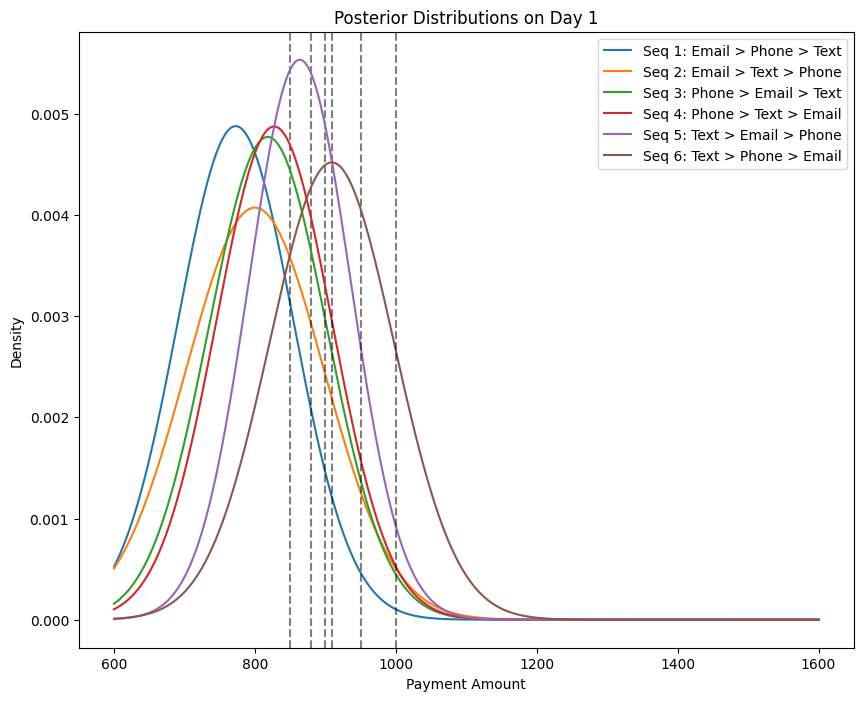

Sequence 1 (Email > Phone > Text) was assigned to 0 customers.
Sequence 2 (Email > Text > Phone) was assigned to 6 customers.
Sequence 3 (Phone > Email > Text) was assigned to 6 customers.
Sequence 4 (Phone > Text > Email) was assigned to 8 customers.
Sequence 5 (Text > Email > Phone) was assigned to 14 customers.
Sequence 6 (Text > Phone > Email) was assigned to 26 customers.
--------------------------------------------------
Day 2 Simulation


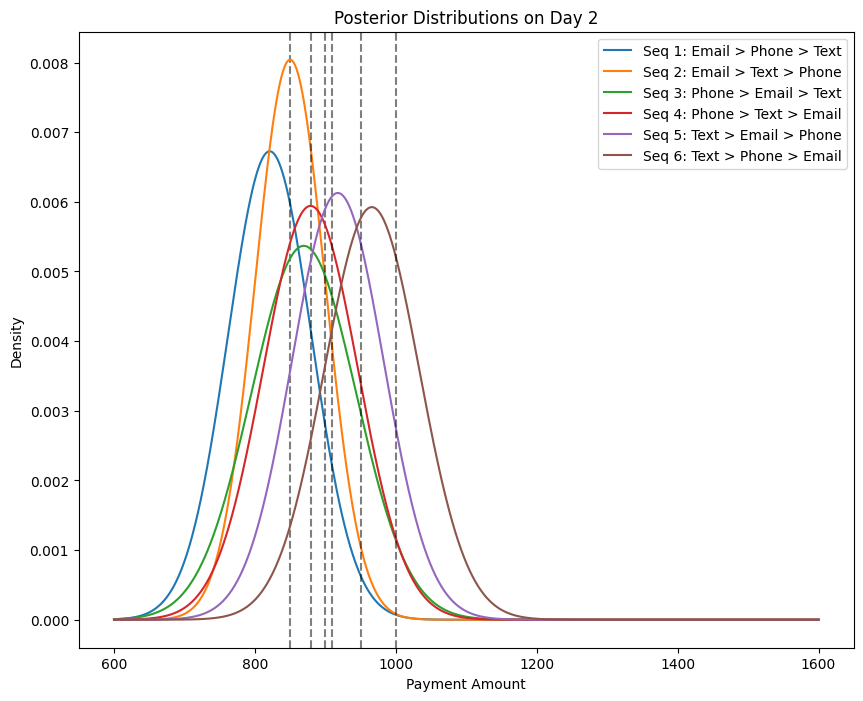

Sequence 1 (Email > Phone > Text) was assigned to 0 customers.
Sequence 2 (Email > Text > Phone) was assigned to 3 customers.
Sequence 3 (Phone > Email > Text) was assigned to 7 customers.
Sequence 4 (Phone > Text > Email) was assigned to 3 customers.
Sequence 5 (Text > Email > Phone) was assigned to 14 customers.
Sequence 6 (Text > Phone > Email) was assigned to 33 customers.
--------------------------------------------------
Day 3 Simulation


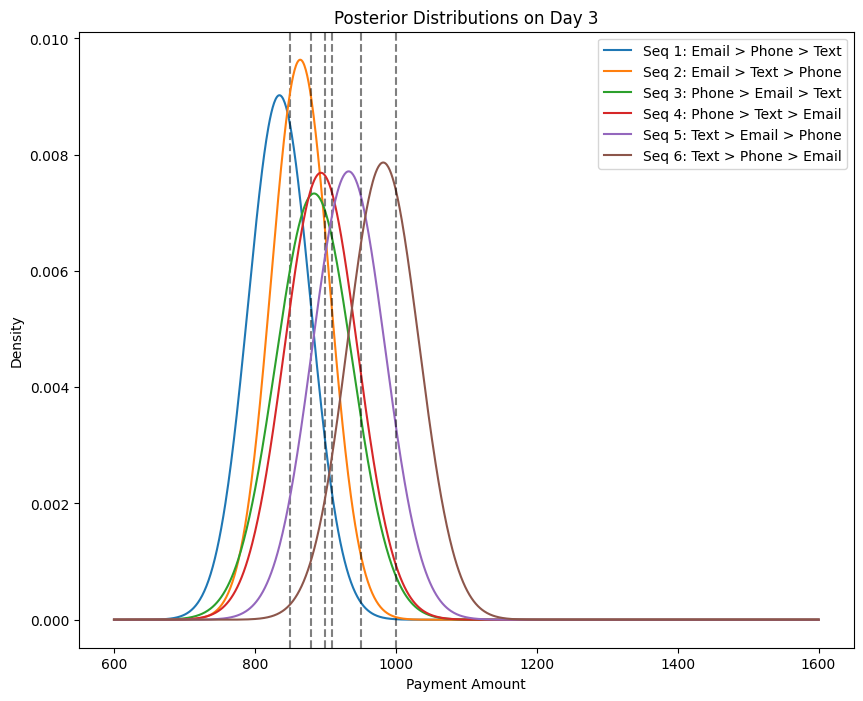

Sequence 1 (Email > Phone > Text) was assigned to 0 customers.
Sequence 2 (Email > Text > Phone) was assigned to 0 customers.
Sequence 3 (Phone > Email > Text) was assigned to 4 customers.
Sequence 4 (Phone > Text > Email) was assigned to 6 customers.
Sequence 5 (Text > Email > Phone) was assigned to 20 customers.
Sequence 6 (Text > Phone > Email) was assigned to 30 customers.
--------------------------------------------------
Day 4 Simulation


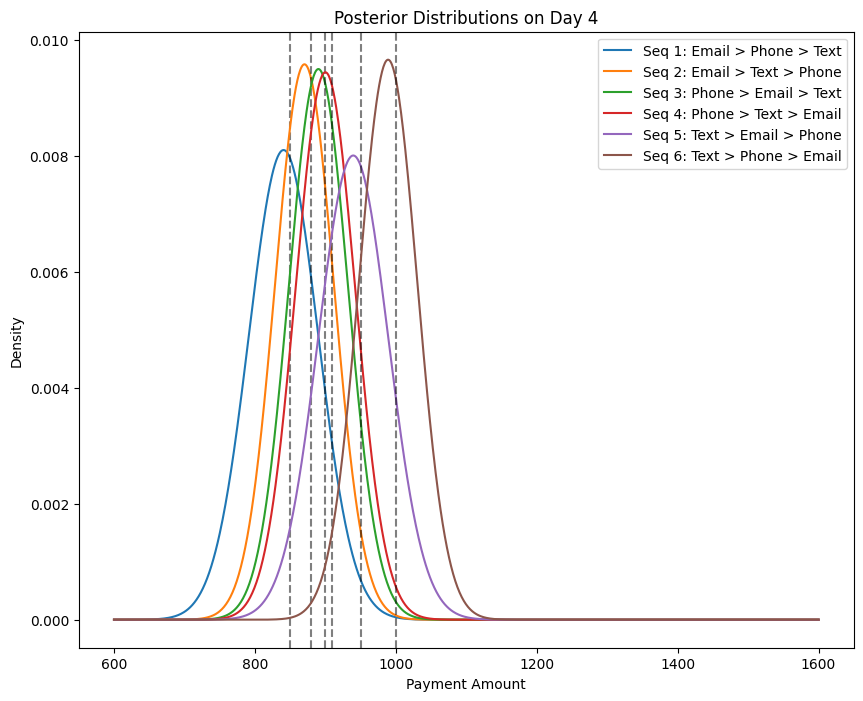

Sequence 1 (Email > Phone > Text) was assigned to 0 customers.
Sequence 2 (Email > Text > Phone) was assigned to 1 customers.
Sequence 3 (Phone > Email > Text) was assigned to 0 customers.
Sequence 4 (Phone > Text > Email) was assigned to 1 customers.
Sequence 5 (Text > Email > Phone) was assigned to 9 customers.
Sequence 6 (Text > Phone > Email) was assigned to 49 customers.
--------------------------------------------------
Day 5 Simulation


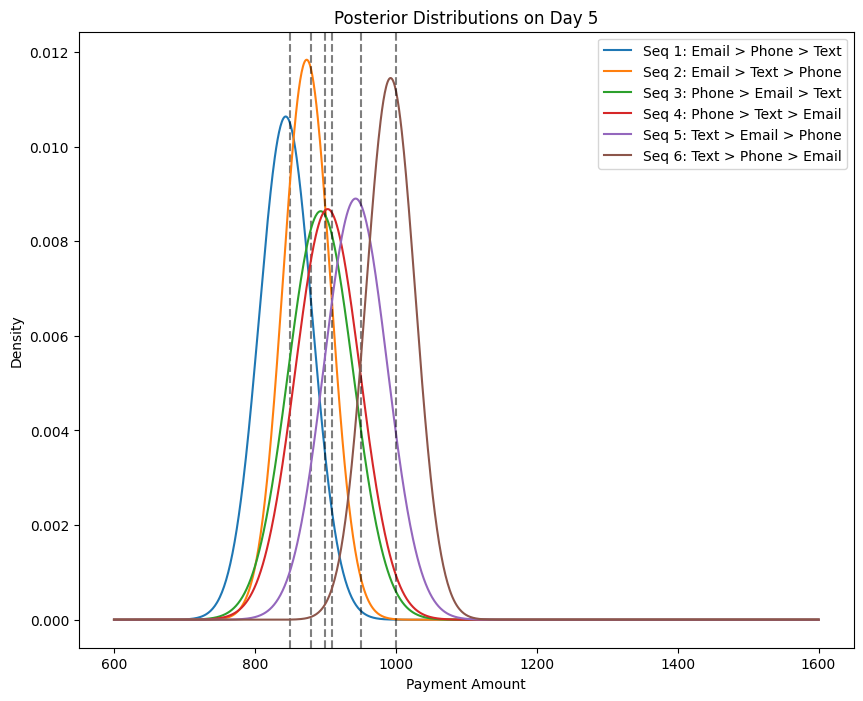

Sequence 1 (Email > Phone > Text) was assigned to 0 customers.
Sequence 2 (Email > Text > Phone) was assigned to 0 customers.
Sequence 3 (Phone > Email > Text) was assigned to 3 customers.
Sequence 4 (Phone > Text > Email) was assigned to 2 customers.
Sequence 5 (Text > Email > Phone) was assigned to 9 customers.
Sequence 6 (Text > Phone > Email) was assigned to 46 customers.
--------------------------------------------------


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, invgamma

# Define the 6 possible sequences (permutations of Email, Phone, Text)
sequences = {
    1: 'Email > Phone > Text',
    2: 'Email > Text > Phone',
    3: 'Phone > Email > Text',
    4: 'Phone > Text > Email',
    5: 'Text > Email > Phone',
    6: 'Text > Phone > Email'
}

# True (but unobserved) payment amounts for each sequence
true_payment_amounts = {
    1: 850,
    2: 880,
    3: 900,
    4: 910,
    5: 950,
    6: 1000
}

# Number of customers per day
num_customers_per_day = 60

# Initialize the prior parameters for Normal-Gamma distributions
prior_mean = 0000
prior_variance = 200**2  # Prior variance
alpha = 1  # Prior shape parameter (related to variance)
beta = prior_variance  # Prior scale parameter (related to variance)

# Posterior parameters for each sequence
posteriors = {i: {'mean': prior_mean, 'variance': prior_variance, 'alpha': alpha, 'beta': beta}
              for i in sequences.keys()}

# Function to simulate customer payment amounts based on true rates
def simulate_payments(true_amounts, num_customers):
    payments = {}
    for seq, amount in true_amounts.items():
        # Simulate payment amounts for each sequence based on the true payment amount
        payments[seq] = np.full(num_customers // len(true_amounts), amount)
    return payments

# Function to update posteriors based on observed payments
def update_posteriors(posteriors, payments):
    for seq, outcomes in payments.items():
        n = len(outcomes)
        mean_outcome = np.mean(outcomes)
        posteriors[seq]['mean'] = (posteriors[seq]['mean'] * posteriors[seq]['alpha'] + n * mean_outcome) / (posteriors[seq]['alpha'] + n)
        posteriors[seq]['alpha'] += n / 2
        posteriors[seq]['beta'] += 0.5 * np.sum((outcomes - mean_outcome) ** 2)
    return posteriors

# Function to plot posterior distributions
def plot_posteriors(posteriors, day):
    plt.figure(figsize=(10, 8))
    x = np.linspace(600, 1600, 1000)
    for seq, params in posteriors.items():
        sampled_variance = invgamma.rvs(params['alpha'], scale=params['beta'])
        y = norm.pdf(x, loc=params['mean'], scale=np.sqrt(sampled_variance))
        plt.plot(x, y, label=f"Seq {seq}: {sequences[seq]}")
        plt.axvline(true_payment_amounts[seq], color='k', linestyle='--', alpha=0.5)
    plt.title(f'Posterior Distributions on Day {day}')
    plt.xlabel('Payment Amount')
    plt.ylabel('Density')
    plt.legend()
    plt.show()

# Simulation over 5 days
for day in range(1, 6):
    print(f"Day {day} Simulation")

    # Simulate payments for Day 1
    payments = simulate_payments(true_payment_amounts, num_customers_per_day)

    # Update posteriors based on observed payments
    posteriors = update_posteriors(posteriors, payments)

    # Plot the posterior distributions
    plot_posteriors(posteriors, day)

    # Assign customers based on Thompson Sampling
    assigned_sequences = []
    for _ in range(num_customers_per_day):
        sampled_means = {seq: norm.rvs(loc=p['mean'], scale=np.sqrt(invgamma.rvs(p['alpha'], scale=p['beta']))) for seq, p in posteriors.items()}
        chosen_sequence = max(sampled_means, key=sampled_means.get)
        assigned_sequences.append(chosen_sequence)

    # Count the number of customers assigned to each sequence
    assignments_count = {seq: assigned_sequences.count(seq) for seq in posteriors.keys()}

    for seq, count in assignments_count.items():
        print(f"Sequence {seq} ({sequences[seq]}) was assigned to {count} customers.")
    print("-" * 50)